In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils

In [2]:
%matplotlib inline

## Set of problems 1
These cells have trouble loading:
- Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
- Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
- Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
- Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
- Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
- Error finding structures for: N025-685221-PG, dropping from dataframe
- Error finding structures for: N064-68221-JN, dropping from dataframe
- Error finding structures for: N051-685221 -YP, dropping from dataframe
- Error finding structures for: N064-685221-JN, dropping from dataframe
- Error finding structures for: N024-648434-SS, dropping from dataframe

In [3]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


# Set of problems 2
The next problem is inconsistency in the spacing between nodes in the reconstruction. We can exclude the previous problem cells. We find two cells with average distances between nodes to be an order of magnitude smaller than the other cells.
- 'N001-685221-PG'
- 'N016-685221-PG'

In [4]:
names = dataDF['Graph'].values
means = {}
for name in names:
    g = graphs[name]
    x = [g.edges[e]['weight'] for e in g.edges]
    means[name] = np.mean(x)

Text(0.5, 0, 'cells')

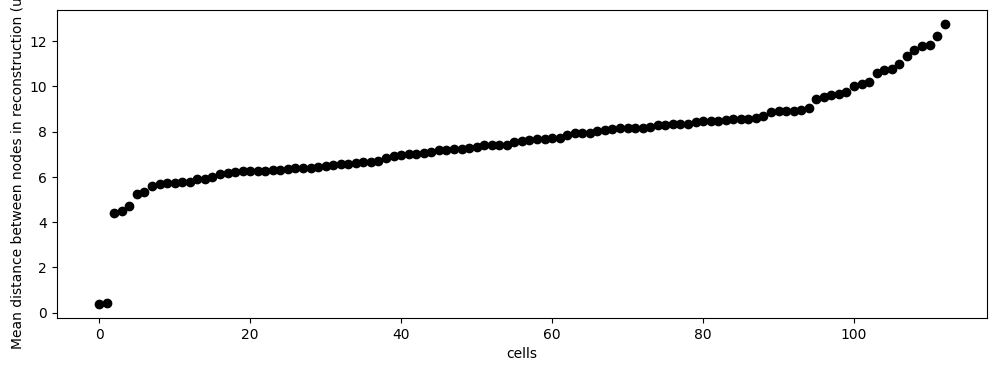

In [5]:
plt.figure(figsize=(12,4))
plt.plot(np.sort([means[x] for x in means]),'ko')
plt.ylabel('Mean distance between nodes in reconstruction (um)')
plt.xlabel('cells')

In [6]:
print([x for x in means if means[x] < 2])

['N001-685221-PG', 'N016-685221-PG']


# Set of problems 3

The next problem is individual edges that are outliers. This cell has a edge that is 3000 um long. There are plenty of cells that have edges over 100um long.
- N006-685222-DS: (1, 314), weight:3061.804895040613

In [7]:
name = 'N006-685222-DS'
TOLERANCE = 500
for name in names:
    for e in graphs[name].edges:
        if graphs[name].edges[e]['weight'] > TOLERANCE:
            print('{}: {}, weight: {}'.format(name,e, graphs[name].edges[e]['weight']))

N006-685222-DS: (1, 314), weight: 3061.804895040613
